<a href="https://colab.research.google.com/github/bobroberts2639/Pangolin-Security-Consulting-Services-tutte-institute-acme3/blob/main/acme3_mapping__5_comparing_data_maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Memory Management

To prevent out-of-memory errors, especially when dealing with large datasets, it's good practice to explicitly delete variables that are no longer needed and trigger the garbage collector. This frees up system RAM for subsequent operations.

In [ ]:
# TODO: explain this
# Set this "CONSTANT" to wherever on Hugging Face the output of Notebook #0 is:
REPO_ID_OF_DATA_ON_HUGGING_FACE = "connoiter/acme3-mapping-TEMP"

In [ ]:
!pip install umap-learn
!pip install datamapplot
!pip install fast_hdbscan
!pip install vectorizers

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.6/350.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.1 MB/s eta 0:00:00
  Created wheel for Pyqtree: filename=Pyqtree-1.0.0-py3-none-any.whl size=5969 sha256=2b230a2e4c1822f63cbb2b5dae8d6239d30f42c7ceea1b75f2b2c5e335061c06
  Stored in directory: /root/.cache/pip/wheels/86/02/24/506ac193949f48c8bec599b613d722bd64a83063a190b3bff7
Successfully built Pyqtree
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.1
    Uninstalling dask-2026.1.1:
      Successfully uninstalled dask-2026.1.1
  Attempting uninstall: distributed
    Found existi

In [ ]:
from huggingface_hub import hf_hub_download

def download_from_huggingface(repo_id, filename):
    hf_hub_download(
        repo_id=repo_id,
        local_dir=".",
        filename=filename
    )

download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_bagofwords.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "color_map.json")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_wasserstein.npz")
download_from_huggingface(REPO_ID_OF_DATA_ON_HUGGING_FACE, "cmdlines_labels_hovertext.parquet")


cmdlines_bagofwords.npz:   0%|          | 0.00/257k [00:00<?, ?B/s]

color_map.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

cmdlines_wasserstein.npz:   0%|          | 0.00/79.7M [00:00<?, ?B/s]

cmdlines_labels_hovertext.parquet:   0%|          | 0.00/135k [00:00<?, ?B/s]

# Pre Connoiter


# Comparing data maps

In [this talk](https://docs.google.com/presentation/d/1wIPd4KIlEngB43lmyM-W2GoChWyHBf-cDlk4sdsYgD4/edit#slide=id.g2e9451582b7_0_918),
I displayed a side-by-side view of the data maps of command line embeddings as a [bag of tokens](1%20Command%20lines%20-%20Bags%20of%20words.ipynb) and as [distributions over a cloud of cooccurrence vectors](2%20Command%20lines%20-%20Wasserstein%20embedding.ipynb).
This is a surprisingly tricky thing to produce,
because UMAP produces an intrinsically random projection
(because it relies on a multi-thread stochastic gradient descent).
There are ways to minimize the random differences induced by having to crunch both vector sets through distinct UMAP computations.

---

**Goal of this notebook**: demonstrate how to produce a pair of visually comparable data maps.

---

In [ ]:
import datamapplot as dmp
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import scipy.sparse
import umap
import vectorizers as vz
import vectorizers.transformers as vzt

In [ ]:
import gc

Get the bag-of-words data map.
It is the model that the other data map will be aligned to.
Get also the index that discards the [invalid points](1%20Command%20lines%20-%20Bags%20of%20words.ipynb#invalid) from the bag of words: we can only compare actual valid embeddings.
Thus, our side-by-side plot will involve a restriction of the Wasserstein embedding data map to this set of valid points.

In [ ]:
with np.load("cmdlines_bagofwords.npz") as store_bagofwords:
    index_valid = store_bagofwords["index_valid"]
    bagofwords_dmap_valid = store_bagofwords["datamap"][index_valid]

In [ ]:
del store_bagofwords
gc.collect()

13899

Fetch the Wasserstein embedding.

In [ ]:
with np.load("cmdlines_wasserstein.npz") as store_wasserstein:
    cmdlines_wasserstein = store_wasserstein["cmdlines"]

In [ ]:
del store_wasserstein
gc.collect()

11

We now crunch the UMAP compression of the Wasserstein embedding, but with a twist:
we initialize the embedding with the data map we want to compare with,
in the hope that the only differences that get derived from this starting point stem from differences between embedding methods.

In [ ]:
%%time
wasserstein_dmap = umap.UMAP(metric="cosine", init=bagofwords_dmap_valid, verbose=True)\
    .fit_transform(cmdlines_wasserstein[index_valid])

UMAP(angular_rp_forest=True, init=array([[ -1.2763166, 7.4301786],
       [ -1.2769916, 7.4307365],
       [  4.521625 , 17.327806 ],
       ...,
       [-12.397016 , 8.440526 ],
       [  5.641823 , 8.577817 ],
       [  5.5387325, 8.424859 ]], dtype=float32), metric='cosine', verbose=True)
Wed Jul 15 05:34:51 2026 Construct fuzzy simplicial set
Wed Jul 15 05:34:52 2026 Finding Nearest Neighbors
Wed Jul 15 05:34:52 2026 Building RP forest with 14 trees
Wed Jul 15 05:34:56 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Wed Jul 15 05:35:11 2026 Finished Nearest Neighbor Search
Wed Jul 15 05:35:16 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Wed Jul 15 05:35:47 2026 Finished embedding
CPU times: user 1min 11s, sys: 1.26 s, total: 1min 12s
Wall time: 55.5 s


Finally, we calculate a [Procrustes alignment](https://en.wikipedia.org/wiki/Procrustes_analysis) between the two maps.

In [ ]:
bagofwords_dmap_a, wasserstein_dmap_a = vz.utils.procrustes_align(bagofwords_dmap_valid, wasserstein_dmap, scale_to="first")

In [ ]:
# The original dmaps are no longer needed after alignment
del bagofwords_dmap_valid
del wasserstein_dmap
gc.collect()

148670

Get the plotting metadata generated in notebook 1,
restrict it to valid points.

In [ ]:
metadata_cmdlines_valid = pd.read_parquet("cmdlines_labels_hovertext.parquet").iloc[index_valid]
metadata_cmdlines_valid

,labels,hover_text
0,Unlabelled,"""%systemroot%\system32\csrss.exe"""
1,Unlabelled,"(126x) ""%systemroot%\system32\csrss.exe"" objec..."
2,Unlabelled,"""%systemroot%\system32\musnotificationux.exe"" ..."
3,Unlabelled,"""%systemroot%\system32\musnotificationux.exe"" ..."
4,Unlabelled,"""%systemroot%\system32\musnotificationux.exe"" ..."
...,...,...
31038,Unlabelled,"""systemroot\system32\smss.exe"" 00000170 0000008c"
31039,Unlabelled,"""systemroot\system32\smss.exe"" 00000174 0000008c"
31040,Unlabelled,"""systemroot\system32\smss.exe"" 00000180 0000008c"
31041,bash.exe,"(80x) ""usr\bin\bash.exe"" --norc -c ""export pat..."


Get also the color map generated in notebook 1.

In [ ]:
label_color_map = json.loads(Path("color_map.json").read_text(encoding="utf-8"))
label_color_map

{'svchost.exe': '#0c71ff',
 'conhost.exe': '#ca2800',
 'taskhostw.exe': '#ef24aa',
 'microsoftedgeupdate.exe': '#000096',
 'mscorsvw.exe': '#e7f700',
 'mousocoreworker.exe': '#1c5951',
 'msedge.exe': '#00d2ff',
 'sppsvc.exe': '#55a282',
 'mergehelper.exe': '#590000',
 'git.exe': '#65008e',
 'backgroundtaskhost.exe': '#a20441',
 'bash.exe': '#ffa6aa',
 'ngen.exe': '#b604c6',
 'cmd.exe': '#410039',
 'wmiprvse.exe': '#00650c',
 'compattelrunner.exe': '#0096a6',
 'wermgr.exe': '#00a200',
 'ls.exe': '#ffb6f3',
 'googleupdate.exe': '#fb2d6d',
 'reg.exe': '#0431ff',
 'rundll32.exe': '#24dfc6',
 'wsqmcons.exe': '#eb65ff',
 'ngentask.exe': '#ff8e31',
 'powershell.exe': '#8e006d',
 'python.exe': '#14ff9e',
 'Unlabelled': '#dddddd'}

Now, we produce a static figure of both data maps respectively,
using corresponding parameters.
To not spoil the surprise, we delay the showing of the data map figures produced by `datamapplot.create_plot`,
and save them to PNGs that can be shown afterwards.

In [ ]:
%%time
fig, ax = dmp.create_plot(
    bagofwords_dmap_a,
    labels=metadata_cmdlines_valid["labels"],
    title="Process instances",
    sub_title="as bags of information-reweighted parsed command line tokens",
    font_family="Roboto",
    figsize=(8, 8),
    label_font_size=9.,
    use_medoids=True,
    darkmode=False,
    label_color_map=label_color_map,
)
fig.savefig("bagofwords.png", bbox_inches="tight")
plt.close(fig)

Calculating medoids: 100%|██████████| 22/22 [00:06<00:00,  3.23it/s]


CPU times: user 39.8 s, sys: 2.7 s, total: 42.5 s
Wall time: 43.1 s


In [ ]:
plt.close(fig)
del fig, ax
gc.collect()

84528

In [ ]:
%%time
fig, _ = dmp.create_plot(
    wasserstein_dmap_a,
    labels=metadata_cmdlines_valid["labels"],
    title="Process instances",
    sub_title="as distributions over a cloud of command line token cooccurrence vectors",
    font_family="Roboto",
    figsize=(8, 8),
    label_font_size=9.,
    use_medoids=True,
    darkmode=False,
    label_color_map=label_color_map,
)
fig.savefig("wasserstein.png", bbox_inches="tight")
plt.close(fig)

Calculating medoids: 100%|██████████| 22/22 [00:00<00:00, 567.67it/s]


CPU times: user 38.8 s, sys: 2.13 s, total: 40.9 s
Wall time: 51.5 s


Now behold! This side-by-side view helps a lot with appreciating the improvements brought on by Wasserstein embedding over the bag-of-words approach.
In particular, observe how each cluster label is _much_ closer to the same-color cluster of points:
this is because the labeled points accrete in a smaller subspace with the Wasserstein embedding,
instead of the tendancy of the bag of words of having related things dispersed all over.


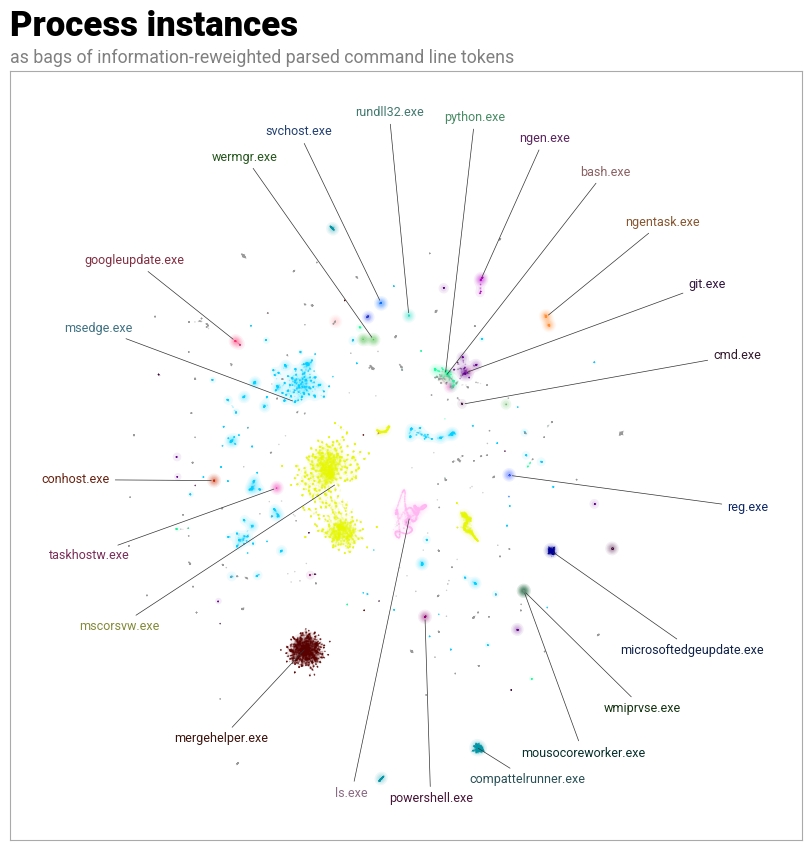
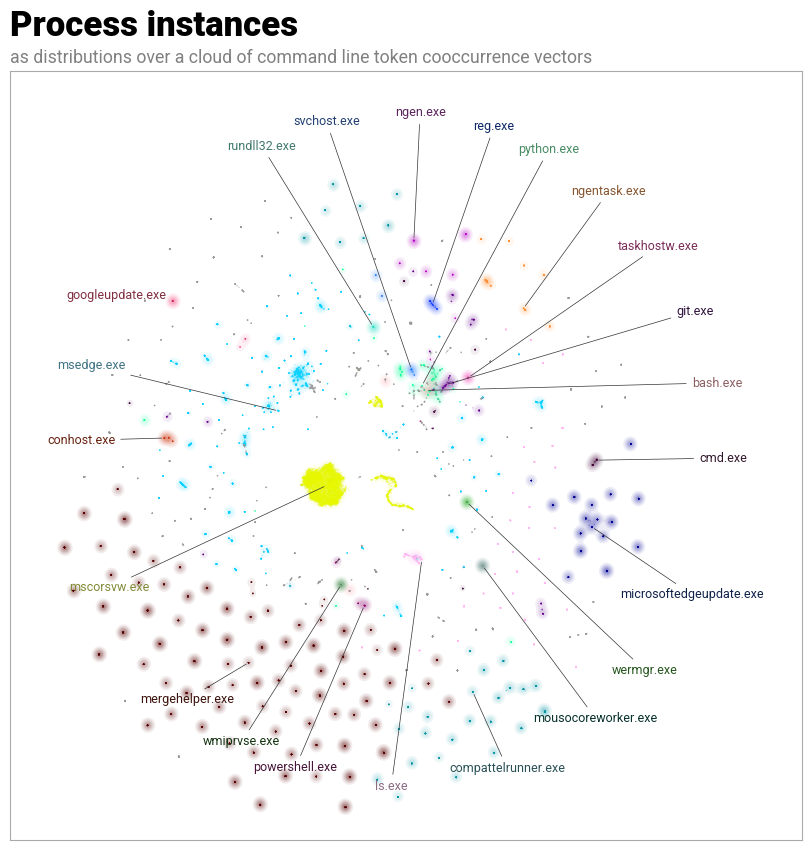

In [ ]:
import base64

def image_to_base64(filepath):
    with open(filepath, "rb") as f:
        return base64.b64encode(f.read()).decode('utf-8')

bagofwords_b64 = image_to_base64("bagofwords.png")
wasserstein_b64 = image_to_base64("wasserstein.png")

html_content = f"""
<style>
    .container {{
        display: flex;
        justify-content: space-around;
        align-items: flex-start;
        flex-wrap: wrap;
    }}
    .figure {{
        flex: 1 1 45%; /* Allow figures to grow and shrink, take up about 45% width */
        margin: 10px; /* Add some space between figures */
        box-sizing: border-box; /* Include padding and border in the element's total width and height */
    }}
    .figure > img {{
        max-width: 100%;
        height: auto;
        display: block;
    }}
</style>
<div class="container">
    <div class="figure"><img src="data:image/png;base64,{bagofwords_b64}"></div>
    <div class="figure"><img src="data:image/png;base64,{wasserstein_b64}"></div>
</div>
"""

from IPython.display import HTML
display(HTML(html_content))